# Lab Exercise 4: Recognizing Digits Using MLP(Multilayer Perceptron) (Question and Answer)

## Q1) How many features represent a single digit image?
**Answer:** 64 features. The image size is 8 x 8, so 8*8 = 64.

## Q2) What does each feature correspond to?
**Answer:** Each feature is one pixel intensity value in the 8x8 grayscale image.

Shape of dataset: (1797, 64)
Number of features per image: 64


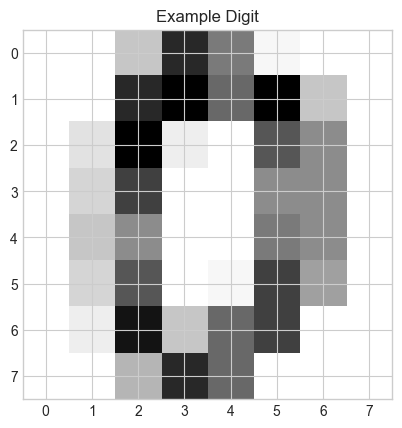

In [120]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import sklearn.metrics as sm

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

print("Shape of dataset:", X.shape)
print("Number of features per image:", X.shape[1])

plt.imshow(digits.images[0])
plt.title("Example Digit")
plt.show()

In [121]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

## Q3) Identify two visually similar digit pairs. How does it affect performance?
**Answer:** Common similar pairs are **3 and 8**, **4 and 9** (also 5 and 6). These pairs may be misclassified more often, reducing accuracy slightly.

## Q4) Why is feature scaling mandatory for MLP?
**Answer:** 

Feature scaling is mandatory for an MLP (Multilayer Perceptron) because neural networks learn using gradient descent, and large differences in feature values can disturb the learning process.

MLP is gradient-based. Scaling keeps feature values in a similar range, improves convergence speed, and usually improves final accuracy. Without scaling, training may be unstable and accuracy can drop.

In [122]:
# Feature scaling + train-test split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train MLP model
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
model.fit(X_train, y_train)

# Prediction and accuracy
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

Accuracy: 0.9805555555555555


In [123]:
dir(sm)

['ConfusionMatrixDisplay',
 'DetCurveDisplay',
 'DistanceMetric',
 'PrecisionRecallDisplay',
 'PredictionErrorDisplay',
 'RocCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_classification',
 '_dist_metrics',
 '_pairwise_distances_reduction',
 '_pairwise_fast',
 '_plot',
 '_ranking',
 '_regression',
 '_scorer',
 'accuracy_score',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'auc',
 'average_precision_score',
 'balanced_accuracy_score',
 'brier_score_loss',
 'calinski_harabasz_score',
 'check_scoring',
 'class_likelihood_ratios',
 'classification_report',
 'cluster',
 'cohen_kappa_score',
 'completeness_score',
 'confusion_matrix',
 'confusion_matrix_at_thresholds',
 'consensus_score',
 'coverage_error',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'd2_pinball_score',
 'd2_tweedie_score',
 'davies_bouldin_score',
 'dcg_score',
 'det_cu

In [124]:
help(MLPClassifier)

Help on class MLPClassifier in module sklearn.neural_network._multilayer_perceptron:

class MLPClassifier(sklearn.base.ClassifierMixin, BaseMultilayerPerceptron)
 |  MLPClassifier(
 |      hidden_layer_sizes=(100,),
 |      activation='relu',
 |      *,
 |      solver='adam',
 |      alpha=0.0001,
 |      batch_size='auto',
 |      learning_rate='constant',
 |      learning_rate_init=0.001,
 |      power_t=0.5,
 |      max_iter=200,
 |      shuffle=True,
 |      random_state=None,
 |      tol=0.0001,
 |      verbose=False,
 |      warm_start=False,
 |      momentum=0.9,
 |      nesterovs_momentum=True,
 |      early_stopping=False,
 |      validation_fraction=0.1,
 |      beta_1=0.9,
 |      beta_2=0.999,
 |      epsilon=1e-08,
 |      n_iter_no_change=10,
 |      max_fun=15000
 |  )
 |
 |  Multi-layer Perceptron classifier.
 |
 |  This model optimizes the log-loss function using LBFGS or stochastic
 |  gradient descent.
 |
 |  .. versionadded:: 0.18
 |
 |  Parameters
 |  ----------
 |

## Q5) How does increasing hidden layers affect learning capacity and overfitting risk?
**Answer:**
- More hidden layers -> higher learning capacity (can learn complex patterns).
- But overfitting risk also increases, especially with small datasets.

## Q6) What does overall accuracy indicate?
**Answer:** Accuracy is the fraction of test digits correctly predicted by the model.

## Q7) Interpret the confusion matrix. Which digits are most misclassified and why?
**Answer:**
- Off-diagonal values show mistakes.
- Digits with similar shapes (like 3/8, 4/9) are usually confused more.
- This occurs because low-resolution 8x8 images may lose fine details.

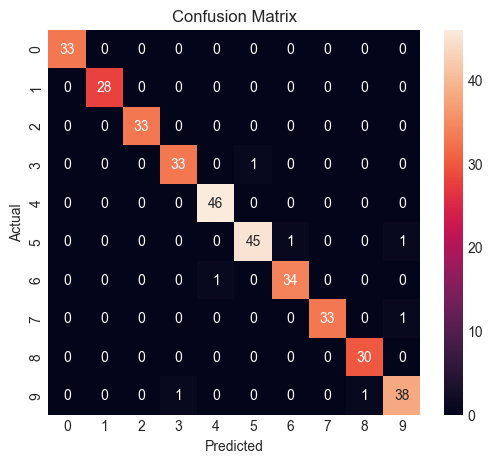

In [125]:
# Confusion matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Q8) Visualize misclassified digits
**Answer:** The following plot shows incorrectly classified samples with predicted and true labels.

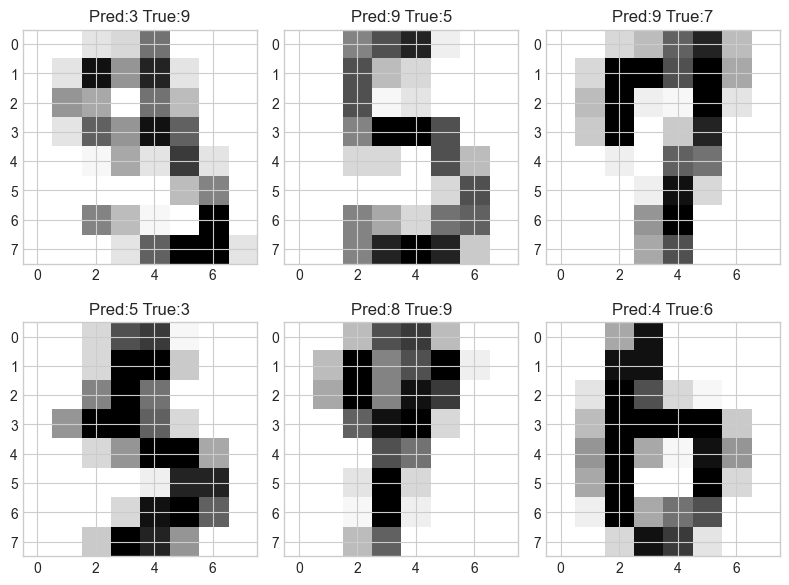

In [126]:
# Visualize misclassified digits
mis = np.where(pred != y_test)

# Use unscaled images for display
_, X_test_raw, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
for i, index in enumerate(mis[0][:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test_raw[index].reshape(8,8))
    plt.title(f"Pred:{pred[index]} True:{y_test[index]}")

plt.tight_layout()
plt.show()

In [127]:
mis

(array([ 52,  71, 133, 149, 159, 244, 339]),)

## Q9) Why does MLP perform better than many basic models for digit recognition?
**Answer:** MLP learns nonlinear patterns and complex pixel relationships better than simple linear models, so it usually gives higher accuracy on handwritten digit data.